In [ ]:
"""
=============================================================================
案例教程 20: 影像组学端到端机器学习流水线 — CT 影像数据
=============================================================================
教学目标: 在影像组学特征 (教程 19 输出) 上跑通【完整的 ML 流程】, 并在每一步
         显式对照前面教程 01-12 的知识点, 让学生看清"从表格数据迁移到影像数据,
         哪些步骤完全相同, 哪些步骤因数据特性而不同".

本脚本 = 一个综合案例, 覆盖机器学习的全部步骤:
  ① EDA           → 对照教程 01
  ② 统计分析      → 对照教程 02
  ③ 预处理        → 对照教程 03/04 (标准化, 防泄漏)
  ④ 特征选择      → 对照教程 05 (★影像组学最常用: LASSO)
  ⑤ 防泄漏        → 对照教程 07 (Pipeline + 仅训练集选择)
  ⑥ 交叉验证      → 对照教程 08 (重复分层 K-Fold)
  ⑦ 建模对比      → 对照教程 09 (LR/SVM/RF/XGBoost/LightGBM)
  ⑧ 类别不平衡    → 对照教程 10 (本数据平衡, 简述)
  ⑨ 校准与 DCA    → 对照教程 11
  ⑩ SHAP 可解释   → 对照教程 12

任务: 用影像组学特征预测 CT 是否增强 (Contrast: 1=增强, 0=平扫), 50/50 平衡二分类.

为什么特征选择用 LASSO?
  - 用户问题: "影像组学特征会很多, 选一个最常用的方法"
  - 答: LASSO (L1 正则逻辑回归) 是影像组学论文 (radiomics signature) 的事实标准.
    原因: ① 自动稀疏 (系数压到 0 = 自动选特征); ② 可解释 (线性系数);
          ③ 与样本量适配 (p≫n 时仍稳定). 见 Aerts et al., Nature 2014.
  - 本脚本采用标准影像组学流程: 方差预筛 → 相关性去冗余 → LASSO 稀疏 → signature

=============================================================================
"""

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, brier_score_loss, accuracy_score,
                             recall_score, precision_score, f1_score,
                             roc_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
import logging as _logging
_logging.getLogger('shap').setLevel(_logging.ERROR)  # 抑制 shap 冗余日志


/home/wjj/miniconda3/envs/radiomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
BASE_DIR = ".."
DATA_DIR = os.path.join(BASE_DIR, "data", "ct_data")
FEATURES_CSV = os.path.join(DATA_DIR, "radiomics_features.csv")  # 教程 19 输出
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
print("\n[0] 加载影像组学特征表 ...")
df = pd.read_csv(FEATURES_CSV)
print(f"    样本数: {len(df)}  |  总列数: {df.shape[1]}")

# 目标变量
y = df['Contrast'].values
# 特征: 临床 Age + 全部影像组学特征
non_feat_cols = ['id', 'Contrast']
feat_cols = [c for c in df.columns if c not in non_feat_cols]
X = df[feat_cols].astype(float).values
feat_names = np.array(feat_cols)
print(f"    特征数: {len(feat_cols)}  (Age + {len(feat_cols) - 1} 影像组学特征)")
print(f"    标签: 增强(1)={int((y == 1).sum())}  平扫(0)={int((y == 0).sum())}  (50/50 平衡)")

n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())


[0] 加载影像组学特征表 ...
    样本数: 100  |  总列数: 96
    特征数: 94  (Age + 93 影像组学特征)
    标签: 增强(1)=50  平扫(0)=50  (50/50 平衡)


In [5]:
# ----------------------------------------------------------------------------
# 防泄漏第 1 步: 先划分 train/test, 之后所有 fit 都只在 train 上 (教程 07)
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"    训练集: {len(X_train)}  测试集: {len(X_test)}  (分层划分, 保留类别比例)")


    训练集: 80  测试集: 20  (分层划分, 保留类别比例)



① EDA 探索性数据分析  (对照教程 01)

  ▶ 特征量级跨度: min=0.00  max=6.51e+09
     → 跨度跨越 13 个数量级, 必须标准化 (教程 03/04)
  ▶ |r|>0.9 的高度相关特征对: 184 对  (说明冗余严重 → 需 LASSO 稀疏)
  [图] 20_eda_correlation.png → 特征相关性热力图已保存


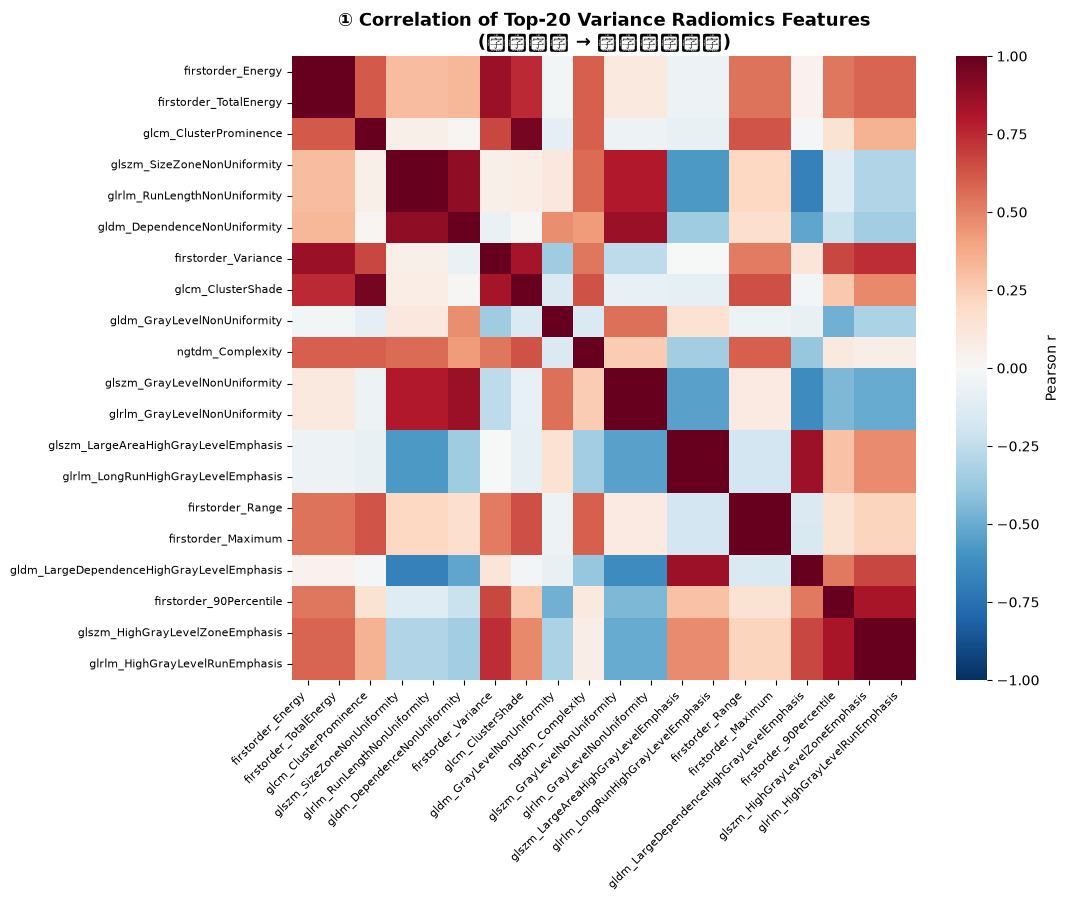

In [6]:

# ============================================================================
# ① EDA — 对照教程 01
# ============================================================================
print("\n" + "=" * 70)
print("① EDA 探索性数据分析  (对照教程 01)")
print("=" * 70)

# 1a. 特征量级跨度 (影像组学特有问题: 跨度极大 → 必须标准化)
ranges = pd.Series(X.max(axis=0) - X.min(axis=0), index=feat_names)
print(f"\n  ▶ 特征量级跨度: min={ranges.min():.2f}  max={ranges.max():.2e}")
print(f"     → 跨度跨越 {np.log10(ranges.max() / (ranges.min() + 1e-9)):.0f} 个数量级, "
      f"必须标准化 (教程 03/04)")

# 1b. 特征相关性热力图 (影像组学特征高度冗余 → 教程 05 第一层)
corr = df[feat_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['f1', 'f2', 'r']
high_corr_pairs = high_corr_pairs[high_corr_pairs['r'] > 0.9]
print(f"  ▶ |r|>0.9 的高度相关特征对: {len(high_corr_pairs)} 对  (说明冗余严重 → 需 LASSO 稀疏)")

# 图: 相关性热力图 (取 top 20 方差特征避免图太密)
top_var = pd.Series(X.std(axis=0), index=feat_names).sort_values(ascending=False).head(20).index
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[top_var].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={'label': 'Pearson r'},
            xticklabels=[t.replace('original_', '') for t in top_var],
            yticklabels=[t.replace('original_', '') for t in top_var])
ax.set_title('① Correlation of Top-20 Variance Radiomics Features\n(冗余严重 → 特征选择必要)',
             fontsize=13, fontweight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right'); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "20_eda_correlation.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 20_eda_correlation.png → 特征相关性热力图已保存")


In [7]:
# ============================================================================
# ② 统计分析 — 对照教程 02
# ============================================================================
print("\n" + "=" * 70)
print("② 统计分析: 单特征组间比较  (对照教程 02)")
print("=" * 70)

# 影像组学特征多为偏态分布 → 用非参数 Mann-Whitney U (而非 T 检验)
# 多重比较: Benjamini-Hochberg FDR 校正 (教程 02)
stat_rows = []
for j, name in enumerate(feat_names):
    g1 = X[y == 1, j]
    g0 = X[y == 0, j]
    u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    # 效应量: rank-biserial correlation r = 1 - 2U/(n1*n0)
    r = 1 - 2 * u / (len(g1) * len(g0))
    stat_rows.append({'feature': name, 'p_value': p, 'effect_r': abs(r)})
stat_df = pd.DataFrame(stat_rows)

# BH-FDR 校正 (Benjamini-Hochberg): 调整后 p = min_{k>=i} (m/k * p_(k))
# 实现: 排序后从最大秩向最小秩取累计最小, 保证单调性
pvals = stat_df['p_value'].values
order = np.argsort(pvals)
ranked = pvals[order]
m = len(pvals)
q = ranked * m / (np.arange(m) + 1)        # q_(i) = (m/i) * p_(i)
fdr = np.minimum.accumulate(q[::-1])[::-1]  # 从尾部累计最小 → 单调
fdr_sorted = np.empty_like(fdr)
fdr_sorted[order] = fdr
stat_df['fdr_bh'] = np.clip(fdr_sorted, 0, 1)
sig = stat_df[stat_df['fdr_bh'] < 0.05].sort_values('fdr_bh')
print(f"\n  ▶ Mann-Whitney U + BH-FDR 校正后显著特征 (FDR<0.05): {len(sig)} / {len(stat_df)}")
print(f"     Top 5 显著特征:")
for _, r in sig.head(5).iterrows():
    print(f"       {r['feature']:<38} p={r['p_value']:.2e}  FDR={r['fdr_bh']:.2e}  |r|={r['effect_r']:.3f}")
stat_df.to_csv(os.path.join(RESULTS_DIR, "20_statistical_tests.csv"), index=False)
print("  📄 20_statistical_tests.csv → 单特征统计检验结果已保存")


② 统计分析: 单特征组间比较  (对照教程 02)

  ▶ Mann-Whitney U + BH-FDR 校正后显著特征 (FDR<0.05): 50 / 94
     Top 5 显著特征:
       original_firstorder_InterquartileRange p=3.23e-09  FDR=1.02e-07  |r|=0.687
       original_firstorder_RobustMeanAbsoluteDeviation p=1.80e-09  FDR=1.02e-07  |r|=0.698
       original_glcm_Imc2                     p=3.25e-09  FDR=1.02e-07  |r|=0.687
       original_firstorder_90Percentile       p=6.18e-09  FDR=1.45e-07  |r|=0.675
       original_gldm_DependenceEntropy        p=1.55e-08  FDR=2.90e-07  |r|=0.657
  📄 20_statistical_tests.csv → 单特征统计检验结果已保存


In [8]:

# ============================================================================
# ③ 预处理 + ④ 特征选择 (LASSO) — 对照教程 03/05, 防泄漏对照 07
# ============================================================================
print("\n" + "=" * 70)
print("③④ 预处理 + 特征选择 (LASSO 影像组学 signature)  (对照教程 03/05/07)")
print("=" * 70)

# --- 防泄漏关键: 全部在 训练集 上 fit ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # 只用 train 的均值/方差
X_test_sc = scaler.transform(X_test)         # test 用 train 的统计量

# --- 影像组学标准特征选择流程 (在训练集上) ---
# 第1步: 去掉零/低方差 (本数据无零方差, 略)
# 第2步: 去冗余 — 任选 |r|>0.9 对中的一个 (保留下来的特征)
corr_train = pd.DataFrame(X_train_sc, columns=feat_names).corr().abs()
upper_t = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))
to_drop = set()
for col in upper_t.columns:
    if col in to_drop:
        continue
    # 与 col 高相关的其它特征加入 to_drop
    high = upper_t.index[upper_t[col] > 0.9].tolist()
    to_drop.update(high)
keep_after_corr = [c for c in feat_names if c not in to_drop]
print(f"\n  ▶ 相关性去冗余 (|r|>0.9): {len(feat_names)} → {len(keep_after_corr)} 特征 "
      f"(剔除 {len(to_drop)} 个冗余)")

# 第3步: LASSO (L1 逻辑回归, CV 选正则强度) — 影像组学 signature 核心
keep_idx = np.array([list(feat_names).index(c) for c in keep_after_corr])
X_train_lasso = X_train_sc[:, keep_idx]

lasso = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 30), penalty='l1', solver='liblinear',
    cv=5, scoring='roc_auc', max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1)
lasso.fit(X_train_lasso, y_train)
best_C = lasso.C_[0]
coef = lasso.coef_.ravel()
sig_mask = coef != 0
signature_feats = np.array(keep_after_corr)[sig_mask]
print(f"  ▶ LASSO (L1, 5-fold CV) 最佳 C={best_C:.4f}")
print(f"  ▶ LASSO 稀疏后非零特征 (radiomics signature): {sig_mask.sum()} 个")
print(f"     signature = {list(signature_feats.tolist())}")

# 保存 signature
with open(os.path.join(RESULTS_DIR, "20_radiomics_signature.txt"), 'w', encoding='utf-8') as f:
    f.write("影像组学 signature (LASSO 选出, 仅在训练集上选择以防泄漏):\n\n")
    for i, c in enumerate(keep_after_corr):
        mark = '★' if coef[i] != 0 else ' '
        f.write(f"  {mark} {c:<40} coef={coef[i]:+.4f}\n")
    f.write(f"\n最佳正则强度 C = {best_C:.4f}\n")
    f.write(f"signature 特征数 = {int(sig_mask.sum())}\n")

# --- 用 signature 特征构建最终特征矩阵 ---
sig_idx = np.array([list(feat_names).index(c) for c in signature_feats])
X_train_sig = X_train_sc[:, sig_idx]
X_test_sig = X_test_sc[:, sig_idx]
print(f"\n  ▶ 后续建模基于 {len(signature_feats)} 个 signature 特征 (p≫n 问题已解决)")


③④ 预处理 + 特征选择 (LASSO 影像组学 signature)  (对照教程 03/05/07)

  ▶ 相关性去冗余 (|r|>0.9): 94 → 39 特征 (剔除 55 个冗余)
  ▶ LASSO (L1, 5-fold CV) 最佳 C=1.8874
  ▶ LASSO 稀疏后非零特征 (radiomics signature): 13 个
     signature = ['original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Kurtosis', 'original_firstorder_Median', 'original_firstorder_Minimum', 'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_glcm_Idn', 'original_gldm_DependenceEntropy', 'original_gldm_DependenceNonUniformity', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glszm_SmallAreaHighGrayLevelEmphasis', 'original_glszm_SmallAreaLowGrayLevelEmphasis']

  ▶ 后续建模基于 13 个 signature 特征 (p≫n 问题已解决)


In [9]:

# ============================================================================
# ⑤⑥ 交叉验证评估稳定性 — 对照教程 08
# ============================================================================
print("\n" + "=" * 70)
print("⑤⑥ 交叉验证评估模型稳定性  (对照教程 08)")
print("=" * 70)

# 重复分层 K-Fold (教程 08): 评估均值+标准差, 衡量稳定性
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)


# ============================================================================
# ⑦ 建模对比 — 对照教程 09
# ============================================================================
print("\n" + "=" * 70)
print("⑦ 建模对比 (5 模型)  (对照教程 09)")
print("=" * 70)

models = {
    'LogReg':  LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    'SVM':     SVC(probability=True, random_state=RANDOM_STATE),
    'RF':      RandomForestClassifier(n_estimators=200, max_depth=8,
                                      random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric='logloss', random_state=RANDOM_STATE,
                                 n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

# --- CV 评估 (在 signature 特征上) ---
print("\n  ▶ 重复分层 5-Fold×10 CV (训练集内):")
print(f"     {'Model':<10} {'AUC_mean':>9} {'AUC_std':>8} {'Acc_mean':>9}")
print(f"     {'-'*10} {'-'*9} {'-'*8} {'-'*9}")
cv_results = {}
for name, model in models.items():
    auc_scores = cross_val_score(model, X_train_sig, y_train, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X_train_sig, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = {'auc': auc_scores, 'acc': acc_scores}
    print(f"     {name:<10} {auc_scores.mean():>9.4f} {auc_scores.std():>8.4f} "
          f"{acc_scores.mean():>9.4f}")



⑤⑥ 交叉验证评估模型稳定性  (对照教程 08)

⑦ 建模对比 (5 模型)  (对照教程 09)

  ▶ 重复分层 5-Fold×10 CV (训练集内):
     Model       AUC_mean  AUC_std  Acc_mean
     ---------- --------- -------- ---------
     LogReg        0.9519   0.0488    0.9025
     SVM           0.9491   0.0508    0.8838
     RF            0.9231   0.0638    0.8550
     XGBoost       0.8944   0.0739    0.8300
     LightGBM      0.9034   0.0721    0.8462



  [图] 20_cv_model_comparison.png → CV 模型对比箱线图已保存


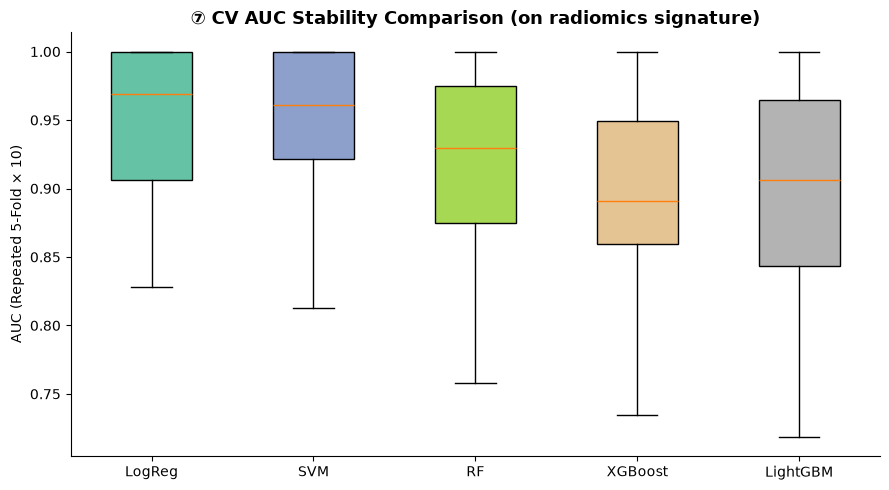

In [10]:

# 图: CV AUC 分布箱线图
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [cv_results[n]['auc'] for n in models]
bp = ax.boxplot(data_box, tick_labels=list(models.keys()), patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(models)))):
    patch.set_facecolor(c)
ax.set_ylabel('AUC (Repeated 5-Fold × 10)')
ax.set_title('⑦ CV AUC Stability Comparison (on radiomics signature)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "20_cv_model_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 20_cv_model_comparison.png → CV 模型对比箱线图已保存")

In [11]:

# --- 在测试集上评估 (holdout) ---
print("\n  ▶ 测试集 (holdout, 20 样本) 最终评估:")
print(f"     {'Model':<10} {'AUC':>7} {'Acc':>7} {'Recall':>7} {'F1':>7} {'Brier':>7}")
print(f"     {'-'*10} {'-'*7} {'-'*7} {'-'*7} {'-'*7} {'-'*7}")
test_results = {}
for name, model in models.items():
    model.fit(X_train_sig, y_train)
    prob = model.predict_proba(X_test_sig)[:, 1]
    pred = (prob >= 0.5).astype(int)
    test_results[name] = {
        'auc': roc_auc_score(y_test, prob),
        'acc': accuracy_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'brier': brier_score_loss(y_test, prob),
        'prob': prob,
    }
    r = test_results[name]
    print(f"     {name:<10} {r['auc']:>7.4f} {r['acc']:>7.4f} {r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} {r['brier']:>7.4f}")

# 选最佳模型 (按测试 AUC)
best_name = max(test_results, key=lambda k: test_results[k]['auc'])
best_model = models[best_name]
best_model.fit(X_train_sig, y_train)
print(f"\n  ▶ 最佳模型 (测试 AUC 最高): {best_name}  AUC={test_results[best_name]['auc']:.4f}")


  ▶ 测试集 (holdout, 20 样本) 最终评估:
     Model          AUC     Acc  Recall      F1   Brier
     ---------- ------- ------- ------- ------- -------
     LogReg      0.9600  0.8500  0.7000  0.8235  0.1044
     SVM         0.8800  0.8000  0.7000  0.7778  0.1330
     RF          0.8700  0.8500  0.7000  0.8235  0.1352
     XGBoost     0.9000  0.8500  0.7000  0.8235  0.1323
     LightGBM    0.9200  0.9000  0.8000  0.8889  0.1096

  ▶ 最佳模型 (测试 AUC 最高): LogReg  AUC=0.9600


In [12]:

# ============================================================================
# ⑧ 类别不平衡 — 对照教程 10
# ============================================================================
print("\n" + "=" * 70)
print("⑧ 类别不平衡  (对照教程 10)")
print("=" * 70)
ratio = n_pos / n_neg
print(f"  ▶ 正负比 = {n_pos}:{n_neg} = 1.0  → 数据完全平衡")
print(f"  → 无需 SMOTE/重采样/class_weight (教程 10 的方法此处可跳过)")
print(f"  → 注意: 若影像组学任务正负失衡 (如肿瘤检出), 仍需用教程 10 的方法")



⑧ 类别不平衡  (对照教程 10)
  ▶ 正负比 = 50:50 = 1.0  → 数据完全平衡
  → 无需 SMOTE/重采样/class_weight (教程 10 的方法此处可跳过)
  → 注意: 若影像组学任务正负失衡 (如肿瘤检出), 仍需用教程 10 的方法



⑨ 校准分析与决策曲线 DCA  (对照教程 11)
  ▶ LogReg 测试 Brier Score = 0.1044  (越小越好, 0=完美)
  [图] 20_calibration_dca.png → 校准曲线+DCA已保存


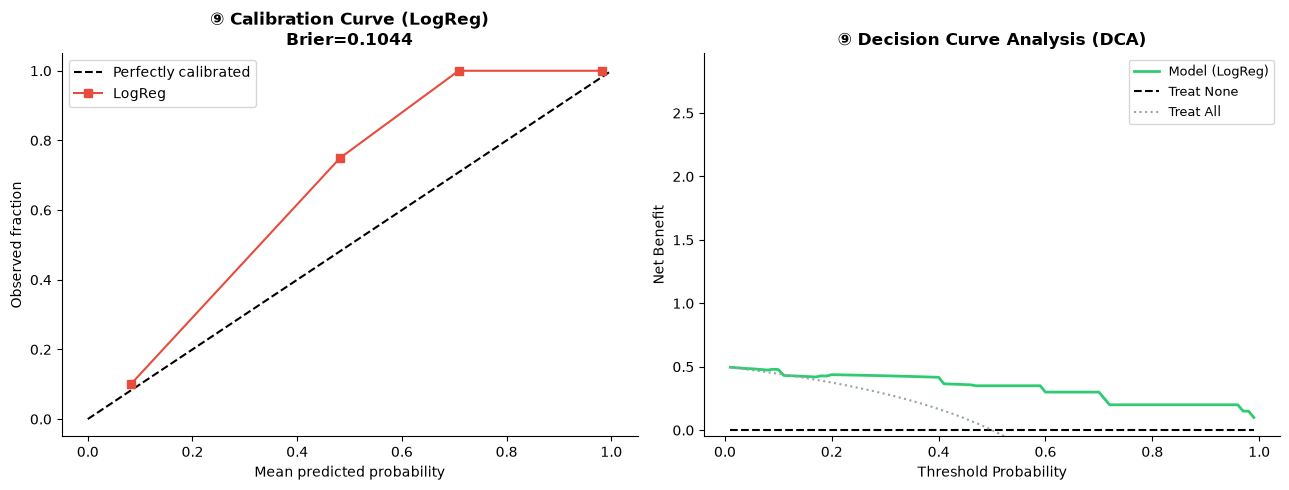

In [13]:

# ============================================================================
# ⑨ 校准与决策曲线 DCA — 对照教程 11
# ============================================================================
print("\n" + "=" * 70)
print("⑨ 校准分析与决策曲线 DCA  (对照教程 11)")
print("=" * 70)

best_prob = test_results[best_name]['prob']
brier = brier_score_loss(y_test, best_prob)
print(f"  ▶ {best_name} 测试 Brier Score = {brier:.4f}  (越小越好, 0=完美)")

# 校准曲线
frac_pos, mean_pred = calibration_curve(y_test, best_prob, n_bins=5, strategy='uniform')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].plot(mean_pred, frac_pos, 's-', color='#e74c3c', label=best_name)
axes[0].set_xlabel('Mean predicted probability'); axes[0].set_ylabel('Observed fraction')
axes[0].set_title(f'⑨ Calibration Curve ({best_name})\nBrier={brier:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# DCA 决策曲线: 净获益 = (TP - FP * pt/(1-pt)) / N
def decision_curve(y_true, prob, pt):
    tp = np.sum((prob >= pt) & (y_true == 1))
    fp = np.sum((prob >= pt) & (y_true == 0))
    n = len(y_true)
    return tp / n - fp * (pt / (1 - pt)) / n

pts = np.linspace(0.01, 0.99, 99)
net_benefit = [decision_curve(y_test, best_prob, pt) for pt in pts]
treat_all = [(y_test.mean() - (1 - y_test.mean()) * pt / (1 - pt)) for pt in pts]

axes[1].plot(pts, net_benefit, color='#2ecc71', lw=2, label=f'Model ({best_name})')
axes[1].plot(pts, [0]*len(pts), 'k--', label='Treat None')
axes[1].plot(pts, treat_all, color='#95a5a6', ls=':', label='Treat All')
axes[1].set_xlabel('Threshold Probability'); axes[1].set_ylabel('Net Benefit')
axes[1].set_title('⑨ Decision Curve Analysis (DCA)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
axes[1].set_ylim(bottom=min(-0.05, min(net_benefit)))

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "20_calibration_dca.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 20_calibration_dca.png → 校准曲线+DCA已保存")


⑩ SHAP 可解释性分析  (对照教程 12)
  [图] 20_shap_beeswarm.png → SHAP 蜂群图(全局)已保存
  [图] 20_shap_importance.png → SHAP 重要性柱状图已保存
  [图] 20_shap_waterfall.png → SHAP 瀑布图(局部)已保存

  ▶ SHAP Top 特征:
     original_firstorder_RobustMeanAbsoluteDeviation |SHAP|=2.0072
     original_firstorder_90Percentile         |SHAP|=1.0629
     original_glszm_SmallAreaHighGrayLevelEmphasis |SHAP|=0.5868
     original_glcm_Idn                        |SHAP|=0.5621
     original_gldm_LargeDependenceHighGrayLevelEmphasis |SHAP|=0.3972


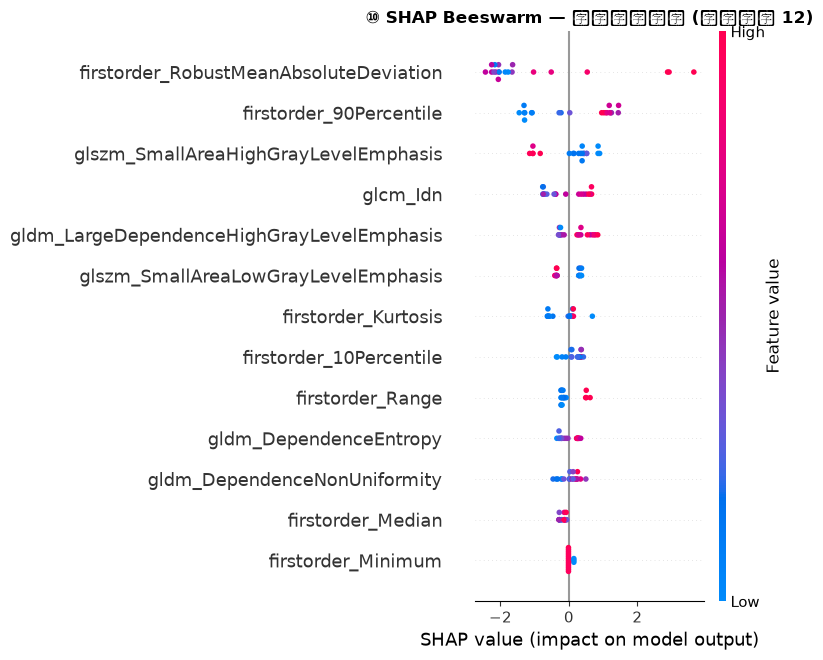

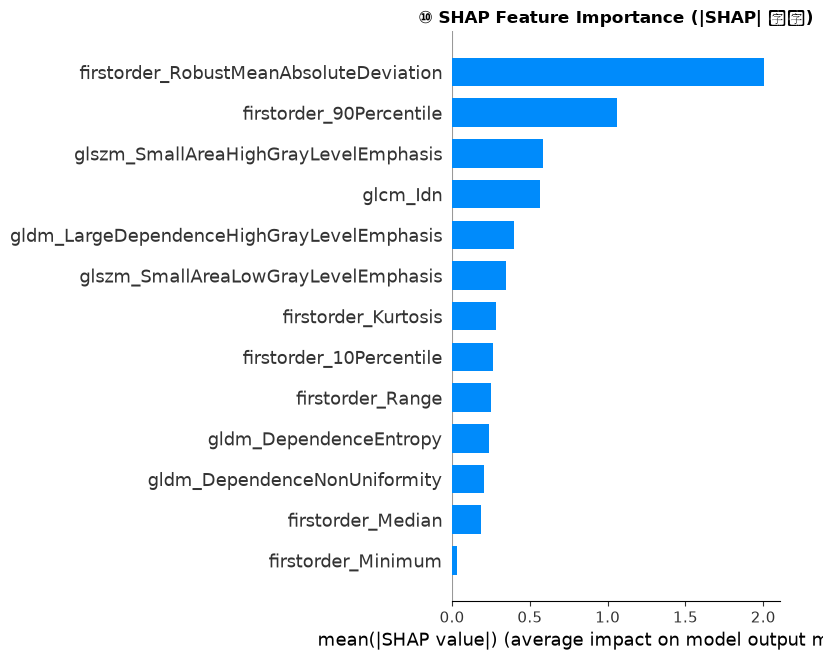

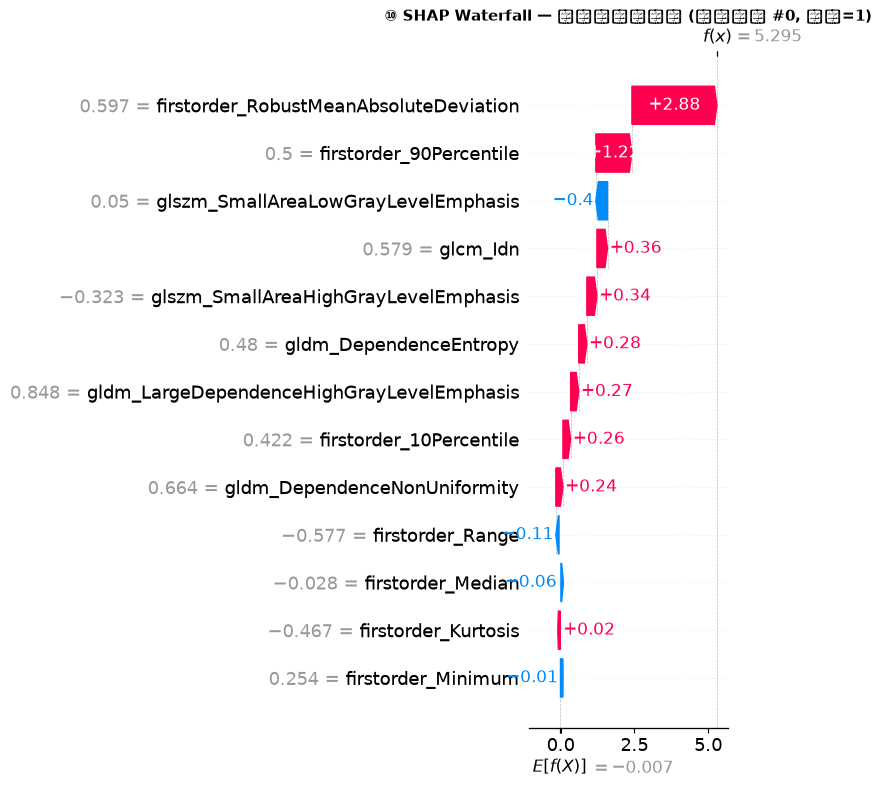

In [14]:

# ============================================================================
# ⑩ SHAP 可解释性 — 对照教程 12
# ============================================================================
print("\n" + "=" * 70)
print("⑩ SHAP 可解释性分析  (对照教程 12)")
print("=" * 70)

# 用树模型做 SHAP (RF/XGBoost/LightGBM 任一); 优先用 XGBoost/LightGBM
shap_model_name = best_name if best_name in ('RF', 'XGBoost', 'LightGBM') else 'XGBoost'
shap_model = models[shap_model_name]
shap_model.fit(X_train_sig, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_sig)
# 二分类 TreeExplainer 返回 log-odds; 也可取正类贡献
if isinstance(shap_values, list):
    sv_plot = shap_values[1]
else:
    sv_plot = shap_values

short_names = [n.replace('original_', '') for n in signature_feats]

# 图1: SHAP 蜂群图 (全局解释)
plt.figure(figsize=(9, max(4, len(signature_feats) * 0.4)))
shap.summary_plot(sv_plot, X_test_sig, feature_names=short_names,
                  show=False, max_display=len(signature_feats))
plt.title('⑩ SHAP Beeswarm — 全局特征贡献 (对照教程 12)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "20_shap_beeswarm.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 20_shap_beeswarm.png → SHAP 蜂群图(全局)已保存")

# 图2: SHAP 柱状图 (特征重要性排序)
plt.figure(figsize=(8, max(3, len(signature_feats) * 0.35)))
shap.summary_plot(sv_plot, X_test_sig, feature_names=short_names,
                  plot_type='bar', show=False, max_display=len(signature_feats))
plt.title('⑩ SHAP Feature Importance (|SHAP| 均值)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "20_shap_importance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 20_shap_importance.png → SHAP 重要性柱状图已保存")

# 图3: 单样本瀑布图 (局部解释)
plt.figure(figsize=(8, max(3, len(signature_feats) * 0.35)))
shap.waterfall_plot(shap.Explanation(values=sv_plot[0],
                                     base_values=explainer.expected_value,
                                     data=X_test_sig[0],
                                     feature_names=short_names),
                    max_display=len(signature_feats), show=False)
plt.title(f'⑩ SHAP Waterfall — 单样本局部解释 (测试样本 #0, 真实={y_test[0]})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "20_shap_waterfall.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 20_shap_waterfall.png → SHAP 瀑布图(局部)已保存")

# SHAP 重要性表格
shap_imp = pd.DataFrame({
    'feature': signature_feats,
    'mean_abs_shap': np.abs(sv_plot).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
shap_imp.to_csv(os.path.join(RESULTS_DIR, "20_shap_importance.csv"), index=False)
print(f"\n  ▶ SHAP Top 特征:")
for _, r in shap_imp.head(5).iterrows():
    print(f"     {r['feature']:<40} |SHAP|={r['mean_abs_shap']:.4f}")